In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1. Loading the Dataset

In [9]:
df = pd.read_csv('train.csv')
print(f'Dataset Shape: {df.shape}')
print(df.info())
df.head()

Dataset Shape: (30000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  ob

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


### 2. Data Preprocessing
Handling missing values, dropping irrelevant columns, encoding categoricals, and scaling.

In [ ]:
# drop rows where target is missing
df = df.dropna(subset=['Loan Sanction Amount (USD)'])
df.drop(columns=['Customer ID', 'Name'], inplace=True, errors='ignore') # dropping irrelevant features 

#fill missing values: median for numerical, mode for categorical
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

#label encoding for categorical features
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['Loan Sanction Amount (USD)'])
y = df['Loan Sanction Amount (USD)']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


Preprocessing completed. Data scaled and encoded.


### 3. Exploratory Data Analysis & Visualization

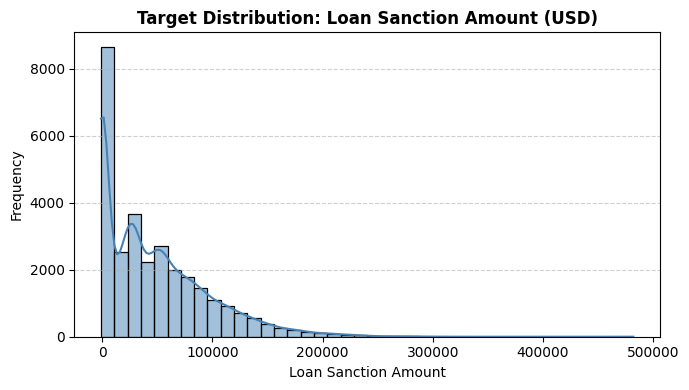

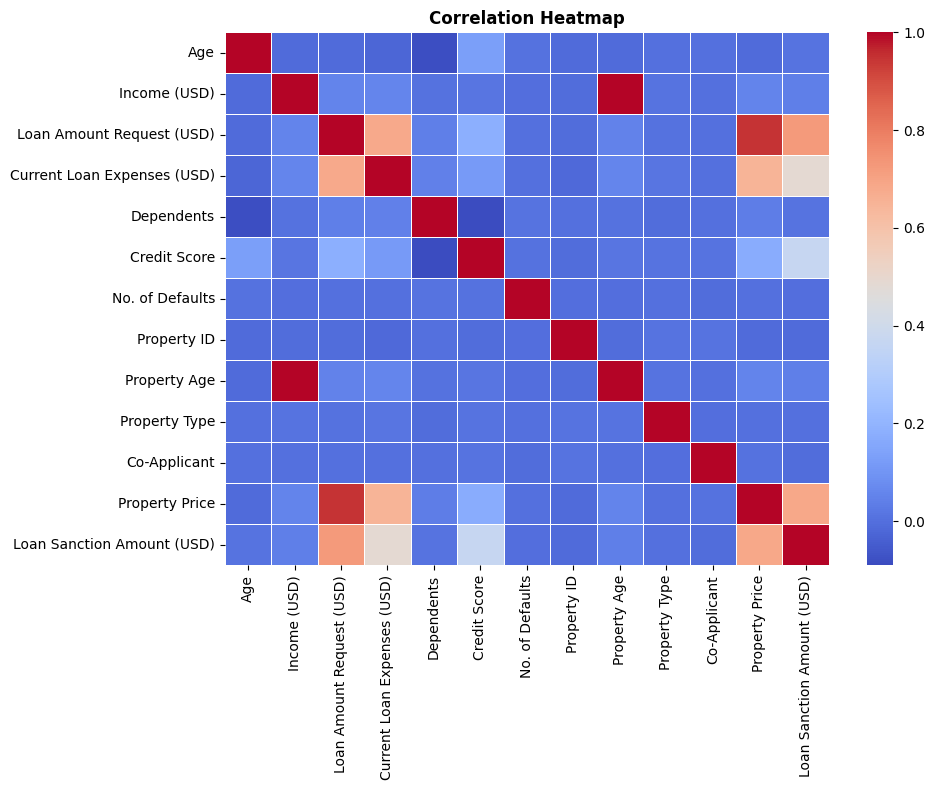

In [ ]:
# target Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['Loan Sanction Amount (USD)'].dropna(), bins=40, kde=True, color='steelblue')
plt.title('Target Distribution: Loan Sanction Amount (USD)', fontweight='bold')
plt.xlabel('Loan Sanction Amount'); plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('figures3/target_distribution.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# correlation Heatmap for numerical features
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('figures3/target_distribution.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

### 4. Feature Selection (ANOVA)
Using `f_regression` to select the top features relevant to the continuous target.

Top 10 Selected Features:
['Income (USD)', 'Income Stability', 'Profession', 'Location', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Expense Type 1', 'Credit Score', 'Property Age', 'Property Price']


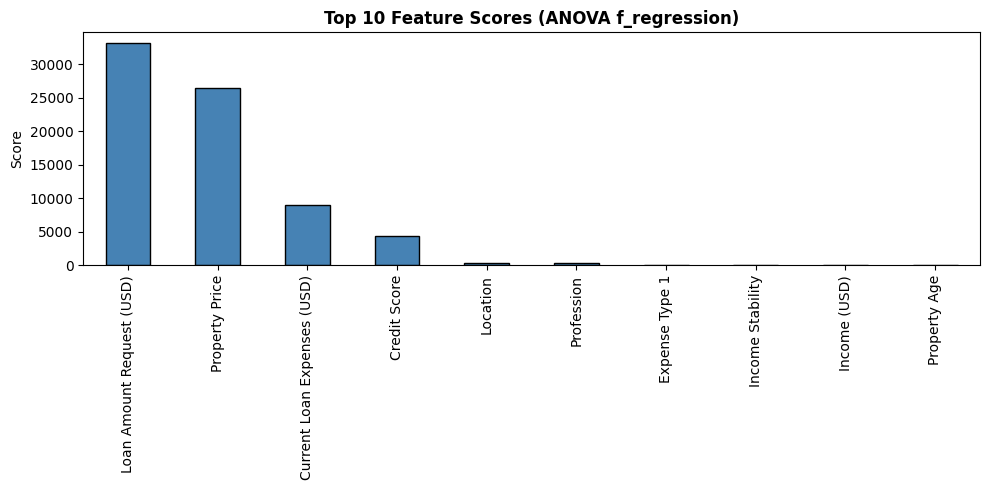

In [ ]:
selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]

print("Top 10 Selected Features:")
print(selected_features.tolist())

scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
scores[:10].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Feature Scores (ANOVA f_regression)', fontweight='bold')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('figures3/anova_feature_scores.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

### 5. Data Splitting
Dividing data into Training (70%), Validation (15%), and Testing (15%) sets.

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_selected, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42) # 70 vs 15 vs 15 split 

print(f"Train size: {X_train.shape[0]} | Validation size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 20761 | Validation size: 4450 | Test size: 4449


### 6. Model Training & Hyperparameter Tuning
Training Linear Regression, Ridge, Lasso, and Elastic Net with Grid Search.

In [ ]:
#linear regression
lr = LinearRegression() # trains standard OLS 
lr.fit(X_train, y_train)

#ridge regression that finds best configuration based on R2 score (L2 regularisation penalty)
# when alpha is too high => the coefficients are strongly pushed toward zero. If regularization becomes too strong, the model can underfit (high bias).
ridge_grid = GridSearchCV(Ridge(), param_grid={'alpha': [0.1, 1.0, 10.0, 100.0]}, scoring='r2', cv=5)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_

#lasso regression (L1 regularisation penalty)

lasso_grid = GridSearchCV(Lasso(max_iter=5000), param_grid={'alpha': [0.1, 1.0, 10.0, 50.0]}, scoring='r2', cv=5)
lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_

#elastic net uses combination of both lasso and ridge 

# alpha is the strength of the regularisation penalty 
# l1_ratio is the relative mix between 
# l1_ratio = 1.0 => pure lasso
# l1_ratio = 0.0 => pure ridge
# l1_ratio = 0.5 => 50/50 blend 
en_grid = GridSearchCV(ElasticNet(max_iter=5000), param_grid={'alpha': [0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}, scoring='r2', cv=5)
en_grid.fit(X_train, y_train)
best_en = en_grid.best_estimator_

print("Table 1: Hyperparameter Tuning Summary")
import pandas as pd
from IPython.display import display
from sklearn.model_selection import cross_validate
import numpy as np

tune_df = pd.DataFrame([
    {'Model': 'Ridge Regression', 'Search Method': 'Grid Search', 'Best Parameters': str(ridge_grid.best_params_), 'Best CV R2': ridge_grid.best_score_},
    {'Model': 'Lasso Regression', 'Search Method': 'Grid Search', 'Best Parameters': str(lasso_grid.best_params_), 'Best CV R2': lasso_grid.best_score_},
    {'Model': 'Elastic Net Regression', 'Search Method': 'Grid Search', 'Best Parameters': str(en_grid.best_params_), 'Best CV R2': en_grid.best_score_}
])
display(tune_df)

print("\nTable 2: Cross-Validation Performance (K=5)")
def get_cv_metrics(model, name, X_t, y_t):
    cv_res = cross_validate(model, X_t, y_t, cv=5, scoring=('neg_mean_absolute_error', 'neg_mean_squared_error', 'r2'))
    return {
        'Model': name,
        'MAE': -cv_res['test_neg_mean_absolute_error'].mean(), # negative scoring metrics of scikit-learn
        'MSE': -cv_res['test_neg_mean_squared_error'].mean(),
        'RMSE': np.sqrt(-cv_res['test_neg_mean_squared_error'].mean()),
        'R2': cv_res['test_r2'].mean()
    }

cv_df = pd.DataFrame([
    get_cv_metrics(lr, "Linear Regression", X_train, y_train),
    get_cv_metrics(best_ridge, "Ridge Regression", X_train, y_train),
    get_cv_metrics(best_lasso, "Lasso Regression", X_train, y_train),
    get_cv_metrics(best_en, "Elastic Net", X_train, y_train)
])
display(cv_df.round(4))

Table 1: Hyperparameter Tuning Summary


,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'alpha': 100.0},0.571371
1,Lasso Regression,Grid Search,{'alpha': 50.0},0.582649
2,Elastic Net Regression,Grid Search,"{'alpha': 0.1, 'l1_ratio': 0.5}",0.583495



Table 2: Cross-Validation Performance (K=5)


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21566.9458,1.033533e+09,32148.6122,0.5591
1,Ridge Regression,21586.3542,1.004451e+09,31693.0776,0.5714
2,Lasso Regression,21545.7261,9.776667e+08,31267.6614,0.5826
3,Elastic Net,21757.7705,9.754580e+08,31232.3237,0.5835


### 7. Performance Evaluation (Test Set) & Residual Analysis

Table 3: Test Set Performance


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21624.0571,9.901925e+08,31467.3237,0.5687
1,Ridge Regression,21632.2953,9.888128e+08,31445.3947,0.5693
2,Lasso Regression,21619.6197,9.891524e+08,31450.7930,0.5692
3,Elastic Net Regression,21825.2837,9.926281e+08,31506.0015,0.5677



Table 4: Coefficient Comparison (Top 3 Features)


,Feature,Linear,Ridge,Lasso,Elastic Net
0,Income (USD),47004.5428,1119.4489,0.0000,117.2765
1,Income Stability,791.1581,772.9262,700.5011,618.0306
2,Profession,-425.6250,-431.1329,-361.9947,-455.7557


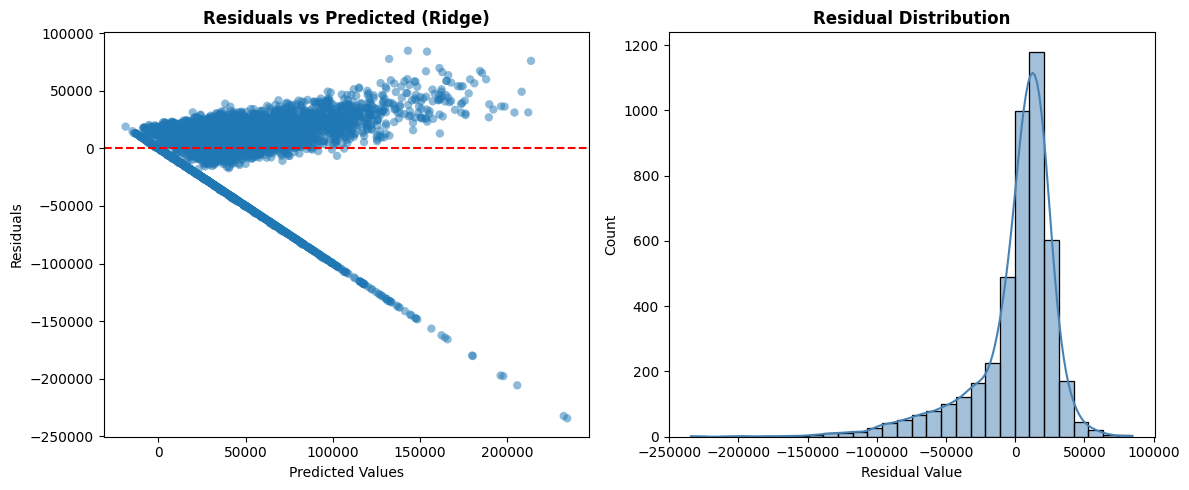

In [ ]:
print("Table 3: Test Set Performance")
def get_metrics(model, name, X_t, y_t):
    preds = model.predict(X_t)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_t, preds),
        'MSE': mean_squared_error(y_t, preds),
        'RMSE': np.sqrt(mean_squared_error(y_t, preds)),
        'R2': r2_score(y_t, preds)
    }

test_df = pd.DataFrame([
    get_metrics(lr, "Linear Regression", X_test, y_test),
    get_metrics(best_ridge, "Ridge Regression", X_test, y_test),
    get_metrics(best_lasso, "Lasso Regression", X_test, y_test),
    get_metrics(best_en, "Elastic Net Regression", X_test, y_test)
])
display(test_df.round(4))

print("\nTable 4: Coefficient Comparison (Top 3 Features)")
coef_df = pd.DataFrame({
    'Feature': selected_features[:3],
    'Linear': lr.coef_[:3],
    'Ridge': best_ridge.coef_[:3],
    'Lasso': best_lasso.coef_[:3],
    'Elastic Net': best_en.coef_[:3]
})
display(coef_df.round(4))

# plotting residuals for the best performing model
import matplotlib.pyplot as plt
import seaborn as sns
y_pred_ridge = best_ridge.predict(X_test)
residuals = y_test - y_pred_ridge

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=y_pred_ridge, y=residuals, alpha=0.5, edgecolor='none', ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Residuals vs Predicted (Ridge)', fontweight='bold')
ax[0].set_xlabel('Predicted Values')
ax[0].set_ylabel('Residuals')

sns.histplot(residuals, bins=30, kde=True, ax=ax[1], color='steelblue')
ax[1].set_title('Residual Distribution', fontweight='bold')
ax[1].set_xlabel('Residual Value')

plt.tight_layout()
plt.savefig('figures3/ridge_residuals.png', format='png', dpi=600, bbox_inches='tight')
plt.show()